In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv("student_scores_clean.csv")

X = df[["Hours"]]
y = df["Scores"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained and ready for predictions.")

Model trained and ready for predictions.


In [7]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Hours": X_test["Hours"].values,
    "Actual Score": y_test.values,
    "Predicted Score": y_pred.round(2)
})
results

,Hours,Actual Score,Predicted Score
0,4.1,34.50000,36.95
1,6.3,48.84902,58.16
2,9.1,83.80000,85.14
3,3.3,27.60000,29.24
4,2.9,23.50000,25.39
5,9.5,90.40000,89.00
6,2.5,23.80000,21.53
7,2.0,22.70000,16.71
8,0.7,1.80000,4.18
9,1.4,9.70000,10.93


In [8]:
new_hours = pd.DataFrame({"Hours": [7.5]})
predicted_score = model.predict(new_hours)

print(f"Predicted score for 7.5 hours of study: {predicted_score[0]:.2f}")

Predicted score for 7.5 hours of study: 69.72


In [9]:
sample_hours = pd.DataFrame({"Hours": [1, 3, 5, 7, 9]})
sample_predictions = model.predict(sample_hours)

for h, s in zip(sample_hours["Hours"], sample_predictions):
    print(f"{h} hours -> predicted score: {s:.2f}")

1 hours -> predicted score: 7.07
3 hours -> predicted score: 26.35
5 hours -> predicted score: 45.63
7 hours -> predicted score: 64.90
9 hours -> predicted score: 84.18


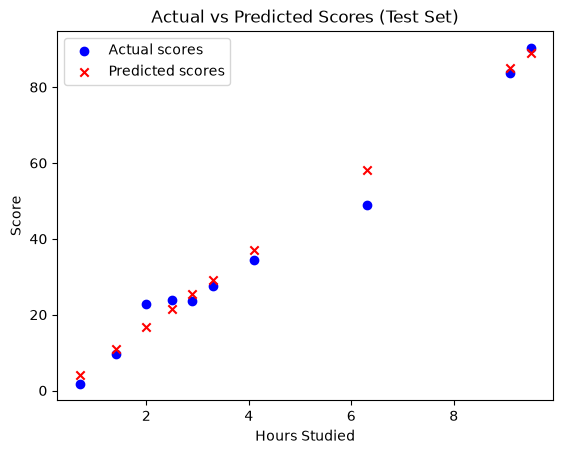

In [10]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, color="blue", label="Actual scores")
plt.scatter(X_test, y_pred, color="red", marker="x", label="Predicted scores")
plt.title("Actual vs Predicted Scores (Test Set)")
plt.xlabel("Hours Studied")
plt.ylabel("Score")
plt.legend()
plt.show()

In [11]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved as model.pkl")

Model saved as model.pkl
